✅ Dataset Created!
       amount  time_hour  distance  frequency  fraud
0  127.168010         20  1.560006          3      0
1  149.134549         12  0.000000          2      0
2    7.956288         11  4.767883          1      0
3   71.316900         11  7.530118          4      0
4   43.767895          9  5.090485          2      0
5  146.783920         17  4.181074          4      0
6   50.519759          9  5.090572          3      0
7   54.621817          9  2.858738          3      0
8  131.646591          9  1.265506          2      0
9   60.837335         18  3.125631          1      0

Dataset Shape : (1000, 5)
Normal Count  : 950
Fraud Count   : 50


/tmp/ipykernel_1202/2431545801.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=df, palette=['steelblue', 'tomato'], ax=axes[0])
/tmp/ipykernel_1202/2431545801.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal', 'Fraud'])


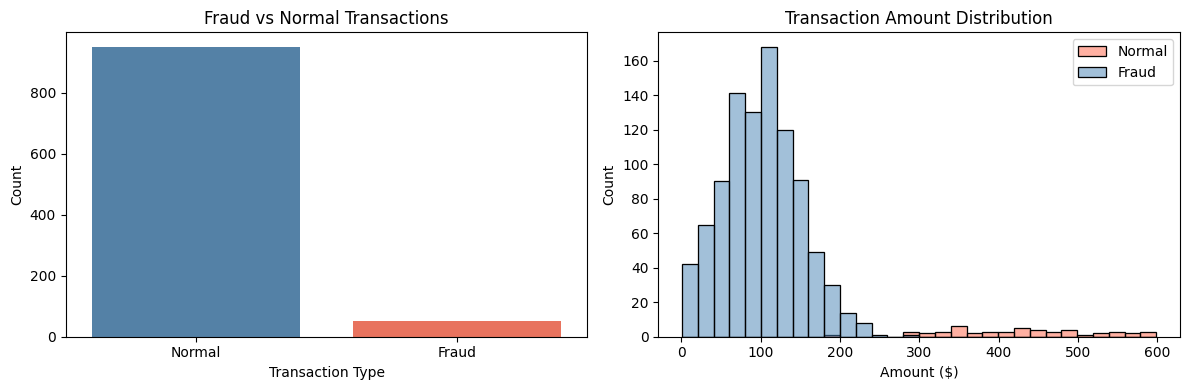

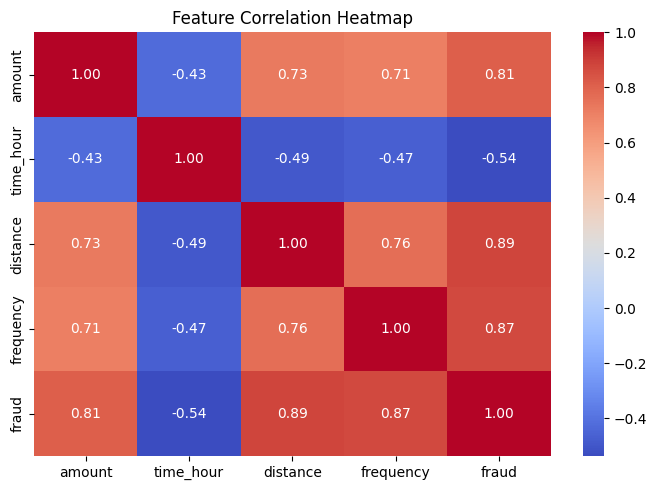

✅ Data Prepared!
   Training samples : 800
   Testing  samples : 200

✅ Model Trained Successfully!

📊 Model Performance:
   Accuracy : 100.00%

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       190
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



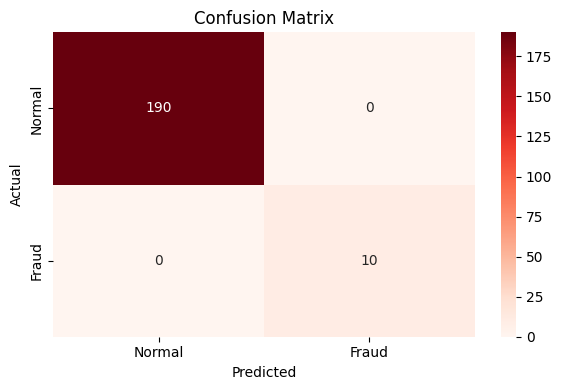

/tmp/ipykernel_1202/2431545801.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Reds_r')


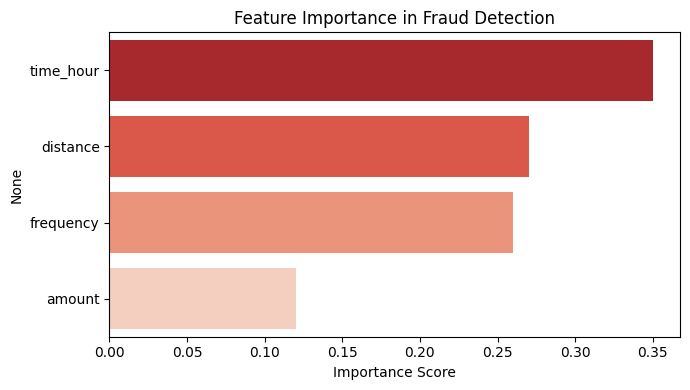


Feature Importance:
   time_hour: 0.3500
   distance: 0.2700
   frequency: 0.2600
   amount: 0.1200

💳 Transaction Details:
   Amount    : $80
   Time      : 14:00 hrs
   Distance  : 3 km
   Frequency : 2 transactions/day
   Result    : ✅ NORMAL
   Confidence: 100.00%

💳 Transaction Details:
   Amount    : $950
   Time      : 3:00 hrs
   Distance  : 75 km
   Frequency : 15 transactions/day
   Result    : 🚨 FRAUDULENT
   Confidence: 100.00%

💳 Transaction Details:
   Amount    : $120
   Time      : 10:00 hrs
   Distance  : 5 km
   Frequency : 3 transactions/day
   Result    : ✅ NORMAL
   Confidence: 100.00%

✅ Credit Card Fraud Detection Complete!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION - COMPLETE CODE
# ============================================================

# CELL 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# ============================================================
# CELL 2 - Create Dataset
np.random.seed(42)
n = 1000

# Generate normal transactions
normal = {
    'amount':    np.random.normal(100, 50, 950).clip(1, 500),
    'time_hour': np.random.randint(8, 22, 950),
    'distance':  np.random.normal(5, 3, 950).clip(0, 20),
    'frequency': np.random.randint(1, 5, 950),
    'fraud':     np.zeros(950, dtype=int)
}

# Generate fraudulent transactions
fraud = {
    'amount':    np.random.normal(400, 100, 50).clip(200, 1000),
    'time_hour': np.random.randint(0, 6, 50),
    'distance':  np.random.normal(50, 20, 50).clip(20, 100),
    'frequency': np.random.randint(8, 20, 50),
    'fraud':     np.ones(50, dtype=int)
}

df = pd.concat([
    pd.DataFrame(normal),
    pd.DataFrame(fraud)
]).reset_index(drop=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Dataset Created!")
print(df.head(10))
print(f"\nDataset Shape : {df.shape}")
print(f"Normal Count  : {df[df['fraud']==0].shape[0]}")
print(f"Fraud Count   : {df[df['fraud']==1].shape[0]}")

# ============================================================
# CELL 3 - Visualize Data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fraud vs Normal count
sns.countplot(x='fraud', data=df, palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Fraud vs Normal Transactions')
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')

# Amount distribution
sns.histplot(data=df, x='amount', hue='fraud', bins=30,
             palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount ($)')
axes[1].legend(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()

# ============================================================
# CELL 4 - Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ============================================================
# CELL 5 - Prepare Data
X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Data Prepared!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")

# ============================================================
# CELL 6 - Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("\n✅ Model Trained Successfully!")

# ============================================================
# CELL 7 - Evaluate Model
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Model Performance:")
print(f"   Accuracy : {accuracy * 100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# ============================================================
# CELL 8 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ============================================================
# CELL 9 - Feature Importance
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Reds_r')
plt.title('Feature Importance in Fraud Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
for feat, score in feat_importance.items():
    print(f"   {feat}: {score:.4f}")

# ============================================================
# CELL 10 - Predict New Transaction
def predict_transaction(amount, time_hour, distance, frequency):
    transaction = np.array([[amount, time_hour, distance, frequency]])
    transaction_scaled = scaler.transform(transaction)
    prediction = model.predict(transaction_scaled)[0]
    probability = model.predict_proba(transaction_scaled)[0]
    label = "🚨 FRAUDULENT" if prediction == 1 else "✅ NORMAL"
    confidence = probability[prediction] * 100
    print(f"\n💳 Transaction Details:")
    print(f"   Amount    : ${amount}")
    print(f"   Time      : {time_hour}:00 hrs")
    print(f"   Distance  : {distance} km")
    print(f"   Frequency : {frequency} transactions/day")
    print(f"   Result    : {label}")
    print(f"   Confidence: {confidence:.2f}%")

# Test transactions
predict_transaction(amount=80,  time_hour=14, distance=3,  frequency=2)
predict_transaction(amount=950, time_hour=3,  distance=75, frequency=15)
predict_transaction(amount=120, time_hour=10, distance=5,  frequency=3)

print("\n✅ Credit Card Fraud Detection Complete!")